In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
sales = pd.read_csv('sales_data.csv')
customers = pd.read_csv('customer_data.csv')

sales.head()
customers.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [9]:
sales.columns = sales.columns.str.strip().str.replace(" ", "_").str.upper()
customers.columns = customers.columns.str.strip().str.replace(" ", "_").str.upper()

print(sales.columns)
print(customers.columns)

Index(['DATE', 'PRODUCT', 'QUANTITY', 'PRICE', 'CUSTOMER_ID', 'REGION',
       'TOTAL_SALES'],
      dtype='str')
Index(['CUSTOMERID', 'TENURE', 'MONTHLYCHARGES', 'TOTALCHARGES', 'CONTRACT',
       'PAYMENTMETHOD', 'PAPERLESSBILLING', 'SENIORCITIZEN', 'CHURN'],
      dtype='str')


In [12]:
merged = pd.merge(
    sales,
    customers,
    left_on='CUSTOMER_ID',
    right_on='CUSTOMERID'
)

merged.head()

,DATE,PRODUCT,QUANTITY,PRICE,CUSTOMER_ID,REGION,TOTAL_SALES,CUSTOMERID,TENURE,MONTHLYCHARGES,TOTALCHARGES,CONTRACT,PAYMENTMETHOD,PAPERLESSBILLING,SENIORCITIZEN,CHURN


In [13]:
merged.drop(columns=['CUSTOMERID'], inplace=True)

In [18]:
total_revenue = merged['TOTAL_SALES'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 0


In [20]:
top_customers = (
    merged.groupby('CUSTOMER_ID')['TOTAL_SALES']
    .sum()
    .sort_values(ascending=False)
)

print(top_customers.head(5))

Series([], Name: TOTAL_SALES, dtype: int64)


In [21]:
best_products = (
    merged.groupby('PRODUCT')['TOTAL_SALES']
    .sum()
    .sort_values(ascending=False)
)

print(best_products)

Series([], Name: TOTAL_SALES, dtype: int64)


In [22]:
region_sales = merged.groupby('REGION')['TOTAL_SALES'].sum()
print(region_sales)

Series([], Name: TOTAL_SALES, dtype: int64)


In [23]:
daily_sales = merged.groupby('DATE')['TOTAL_SALES'].sum()

In [25]:
print("Sales rows:", len(sales))
print("Customer rows:", len(customers))
print("Merged rows:", len(merged))

Sales rows: 100
Customer rows: 500
Merged rows: 0


In [27]:
print(sales['CUSTOMER_ID'].head())
print(customers['CUSTOMERID'].head())

0    CUST001
1    CUST002
2    CUST003
3    CUST004
4    CUST005
Name: CUSTOMER_ID, dtype: str
0    C00001
1    C00002
2    C00003
3    C00004
4    C00005
Name: CUSTOMERID, dtype: str


In [29]:
# Clean SALES customer id
sales['CUSTOMER_ID'] = (
    sales['CUSTOMER_ID']
    .astype(str)
    .str.extract(r'(\d+)')[0]
    .astype(int)
)

# Clean CUSTOMERS customer id
customers['CUSTOMERID'] = (
    customers['CUSTOMERID']
    .astype(str)
    .str.extract(r'(\d+)')[0]
    .astype(int)
)

In [31]:
final = pd.merge(
    sales,
    customers,
    left_on='CUSTOMER_ID',
    right_on='CUSTOMERID',
    how='inner'
)

final.head()

,DATE,PRODUCT,QUANTITY,PRICE,CUSTOMER_ID,REGION,TOTAL_SALES,CUSTOMERID,TENURE,MONTHLYCHARGES,TOTALCHARGES,CONTRACT,PAYMENTMETHOD,PAPERLESSBILLING,SENIORCITIZEN,CHURN
0,2024-01-01,Phone,7,37300,1,East,261100,1,6,64,1540,One year,Credit Card,No,1,0
1,2024-01-02,Headphones,4,15406,2,North,61624,2,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,2024-01-03,Phone,2,21746,3,West,43492,3,27,31,1455,Two year,Credit Card,No,1,0
3,2024-01-04,Headphones,1,30895,4,East,30895,4,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,2024-01-05,Laptop,8,39835,5,North,318680,5,16,185,1023,One year,Electronic Check,No,1,0


In [33]:
final.info()
final.isnull().sum()
final.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   DATE              100 non-null    datetime64[us]
 1   PRODUCT           100 non-null    str           
 2   QUANTITY          100 non-null    int64         
 3   PRICE             100 non-null    int64         
 4   CUSTOMER_ID       100 non-null    int64         
 5   REGION            100 non-null    str           
 6   TOTAL_SALES       100 non-null    int64         
 7   CUSTOMERID        100 non-null    int64         
 8   TENURE            100 non-null    int64         
 9   MONTHLYCHARGES    100 non-null    int64         
 10  TOTALCHARGES      100 non-null    int64         
 11  CONTRACT          100 non-null    str           
 12  PAYMENTMETHOD     100 non-null    str           
 13  PAPERLESSBILLING  100 non-null    str           
 14  SENIORCITIZEN     100 non-null    int6

,DATE,QUANTITY,PRICE,CUSTOMER_ID,TOTAL_SALES,CUSTOMERID,TENURE,MONTHLYCHARGES,TOTALCHARGES,SENIORCITIZEN,CHURN
count,100,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,2024-02-19 12:00:00,4.780000,25808.510000,50.500000,123650.480000,50.500000,36.900000,116.800000,4195.390000,0.540000,0.100000
min,2024-01-01 00:00:00,1.000000,1308.000000,1.000000,6540.000000,1.000000,2.000000,20.000000,416.000000,0.000000,0.000000
25%,2024-01-25 18:00:00,2.750000,14965.250000,25.750000,39517.500000,25.750000,21.000000,75.750000,2326.000000,0.000000,0.000000
50%,2024-02-19 12:00:00,5.000000,24192.000000,50.500000,97955.500000,50.500000,37.500000,121.500000,3915.000000,1.000000,0.000000
75%,2024-03-15 06:00:00,7.000000,38682.250000,75.250000,175792.500000,75.250000,53.000000,157.250000,6270.250000,1.000000,0.000000
max,2024-04-09 00:00:00,9.000000,49930.000000,100.000000,373932.000000,100.000000,71.000000,196.000000,7973.000000,1.000000,1.000000
std,NaN,2.588163,13917.630242,29.011492,100161.085275,29.011492,19.543011,51.270327,2250.746219,0.500908,0.301511


In [35]:
final['TOTAL_SALES'].sum()

np.int64(12365048)

In [36]:
final.groupby('PRODUCT')['TOTAL_SALES'].sum().sort_values(ascending=False)

PRODUCT
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071
Name: TOTAL_SALES, dtype: int64

In [37]:
final.groupby('REGION')['TOTAL_SALES'].sum().sort_values(ascending=False)

REGION
North    3983635
South    3737852
East     2519639
West     2123922
Name: TOTAL_SALES, dtype: int64

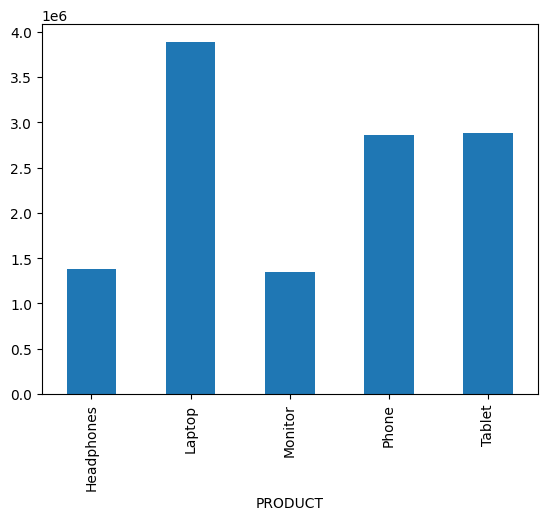

In [38]:
import matplotlib.pyplot as plt

final.groupby('PRODUCT')['TOTAL_SALES'].sum().plot(kind='bar')
plt.show()

In [39]:
final['DATE'] = pd.to_datetime(final['DATE'])
final['Month'] = final['DATE'].dt.month

final.groupby('Month')['TOTAL_SALES'].sum()

Month
1    4120524
2    2656050
3    4485006
4    1103468
Name: TOTAL_SALES, dtype: int64

In [40]:
final.groupby('CUSTOMER_ID')['TOTAL_SALES'].sum().nlargest(10)

CUSTOMER_ID
16    373932
7     363870
83    350888
73    349510
20    333992
84    324144
70    318762
5     318680
65    312564
28    304465
Name: TOTAL_SALES, dtype: int64

In [41]:
final.columns

Index(['DATE', 'PRODUCT', 'QUANTITY', 'PRICE', 'CUSTOMER_ID', 'REGION',
       'TOTAL_SALES', 'CUSTOMERID', 'TENURE', 'MONTHLYCHARGES', 'TOTALCHARGES',
       'CONTRACT', 'PAYMENTMETHOD', 'PAPERLESSBILLING', 'SENIORCITIZEN',
       'CHURN', 'Month'],
      dtype='str')

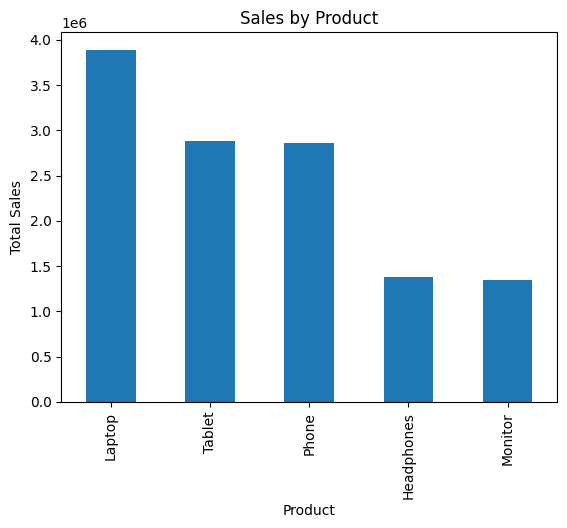

In [42]:
import matplotlib.pyplot as plt

best_products = final.groupby('PRODUCT')['TOTAL_SALES'].sum().sort_values(ascending=False)

plt.figure()
best_products.plot(kind='bar', title='Sales by Product')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.show()

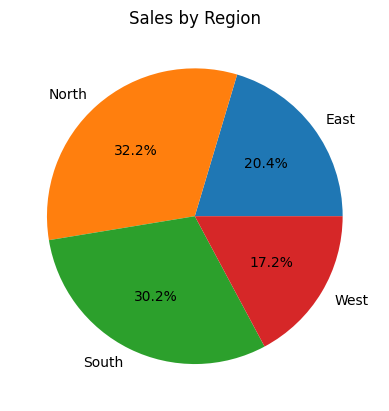

In [43]:
region_sales = final.groupby('REGION')['TOTAL_SALES'].sum()

plt.figure()
region_sales.plot(kind='pie', autopct='%1.1f%%', title='Sales by Region')
plt.ylabel('')
plt.show()

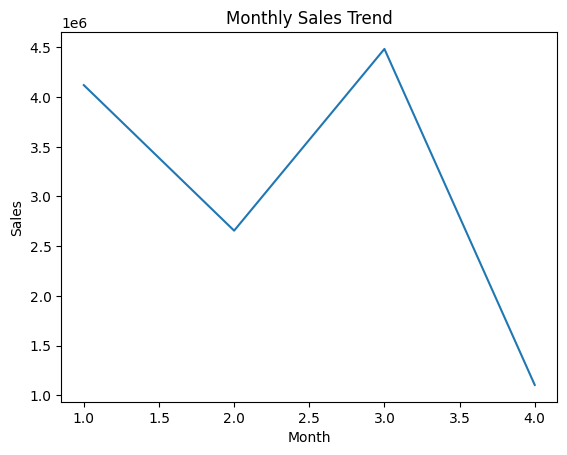

In [44]:
final['DATE'] = pd.to_datetime(final['DATE'])
final['Month'] = final['DATE'].dt.month

monthly_sales = final.groupby('Month')['TOTAL_SALES'].sum()

plt.figure()
monthly_sales.plot(kind='line', title='Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

In [45]:
top_customers = final.groupby('CUSTOMER_ID')['TOTAL_SALES'].sum().nlargest(10)
top_customers

CUSTOMER_ID
16    373932
7     363870
83    350888
73    349510
20    333992
84    324144
70    318762
5     318680
65    312564
28    304465
Name: TOTAL_SALES, dtype: int64

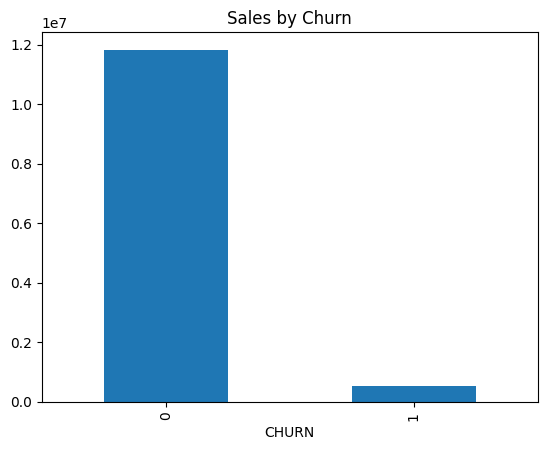

In [46]:
churn_sales = final.groupby('CHURN')['TOTAL_SALES'].sum()

plt.figure()
churn_sales.plot(kind='bar', title='Sales by Churn')
plt.show()

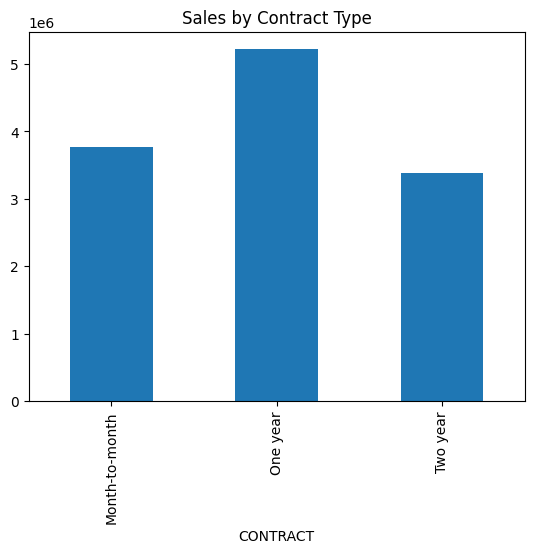

In [47]:
contract_sales = final.groupby('CONTRACT')['TOTAL_SALES'].sum()

plt.figure()
contract_sales.plot(kind='bar', title='Sales by Contract Type')
plt.show()

In [48]:
plt.savefig('chart_name.png')

<Figure size 640x480 with 0 Axes>